In [1]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()
llm = HuggingFaceEndpoint(
    repo_id = "Qwen/Qwen2.5-7B-Instruct",
    task = "conversational"
 )

model = ChatHuggingFace(llm = llm)

c:\Users\sushm\Desktop\Web development\Youtube\AI Engineering\LangGraph\newenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
class LLMState(TypedDict):
    title: str
    outline:str
    detailed: str

In [4]:
def promptChainningOutline(state:LLMState)->LLMState:
    title = state['title']
    prompt = f'Create a breif outline for a blog for thr given topic {title}'
    result = model.invoke(prompt).content
    state['outline'] = result
    return state

In [5]:
def promptChainningDetailed(state:LLMState)->LLMState:
    title = state['title']
    outline = state['outline']
    prompt = f'Create a detailed blog for the given outline {outline} on topic {title}'
    result = model.invoke(prompt).content
    state['detailed'] = result
    return state

In [7]:
graph = StateGraph(LLMState)

graph.add_node('Define_outline',promptChainningOutline)
graph.add_node('Define_detailed',promptChainningDetailed)

graph.add_edge(START,'Define_outline')
graph.add_edge('Define_outline','Define_detailed')
graph.add_edge('Define_detailed',END)

workflow = graph.compile()

In [8]:
initial_state = {'title':"India and it's culture"}
final_result = workflow.invoke(initial_state)
print(final_result)

{'title': "India and it's culture", 'outline': 'Certainly! Below is a brief outline for a blog post on the topic of "India and Its Culture":\n\n---\n\n**India and Its Culture**\n\n**Introduction:**\n- Brief overview of India as a diverse and ancient civilization.\n- Importance of understanding Indian culture in today\'s global context.\n\n**History and Heritage:**\n- Introduction to the historical periods (Vedic, Mauryan, Gupta, Medieval, Modern).\n- Key cultural contributions (philosophy, literature, art, architecture, music, dance).\n- Influence of religion (Hinduism, Islam, Christianity, Sikhism, Buddhism, Jainism).\n\n**Language and Literature:**\n- Overview of major Indian languages (Hindi, Bengali, Telugu, etc.).\n- Important literary works and genres (epics like Ramayana and Mahabharata, classical literature, modern fiction).\n- Contribution to world literature (poets like Rabindranath Tagore, writers like Rabindranath Tagore and Premchand).\n\n**Festivals and Traditions:**\n- M

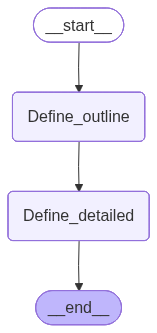

In [9]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())